<a href="https://colab.research.google.com/github/lucilampasquetta-lgtm/portfolio-2026/blob/main/notebooks/TP1_Pasquetta_Lucila.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 1 - Pasquetta Lucila

## Librerías utilizadas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Objetivos del análisis
Se propone realizar una exploracion comparada de las provincias de Chaco y Córdoba en los años 2019 y 2023. Nos enfocamos en indagar que nos ofrecen los datos con respecto a el total de nacimientos y porcentaje de nacimientos correspondientes a las areas mencionados. Ademas exploramos porcentajes de madres adolescentes, de nacimientos prematuros y de nacimientos con bajo peso. El fin es observar diferencias regionales y posibles factores de vulnerabilidad mediante un Análisis Exploratorio de Datos (EDA)



## Análisis Exploratorio de Datos (EDA)

A continuación se presentan las principales columnas del conjunto de datos:

* PROVRES: Código de la jurisdicción de residencia habitual de la madre.

* TIPPARTO: Tipo de parto registrado.

* SEXO: Sexo del nacido vivo.

* IMEDAD: Intervalo de edad de la madre.

* ITIEMGEST: Intervalo de tiempo de gestación (en semanas).

* IMINSTRUC: Intervalo del máximo nivel de instrucción alcanzado por la madre.

* IPESONAC: Intervalo de peso al nacer (en gramos).

* CUENTA: Cantidad de nacidos vivos registrados para cada combinación de variables.

In [2]:
#Tomamos los datos de 2019
from google.colab import drive
df2019= pd.read_csv('/content/drive/MyDrive/nacweb19 - nacweb19.csv')
df2019

,PROVRES,TIPPARTO,SEXO,IMEDAD,ITIEMGEST,IMINSTRUC,IPESONAC,CUENTA
0,38,2,1,4.25 a 29,6.37 a 41,2.Secundaria/Polimodal Incompleta,1.Menos de 2500 gramos,1
1,86,1,2,8.De 45 y más,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,3
2,86,2,1,2.15 a 19,6.37 a 41,1.Hasta Primaria/C.EGB Completa,2.2500 gramos y más,2
3,86,1,2,6.35 a 39,7.42 y más,2.Secundaria/Polimodal Incompleta,2.2500 gramos y más,2
4,34,1,1,1.Menor de 15,6.37 a 41,1.Hasta Primaria/C.EGB Completa,2.2500 gramos y más,22
...,...,...,...,...,...,...,...,...
11283,14,1,2,5.30 a 34,6.37 a 41,3.Secundario/Polimodal Completa y más,3.Sin especificar,3
11284,2,1,2,2.15 a 19,5.32 a 36,1.Hasta Primaria/C.EGB Completa,1.Menos de 2500 gramos,4
11285,34,1,1,6.35 a 39,5.32 a 36,2.Secundaria/Polimodal Incompleta,1.Menos de 2500 gramos,10
11286,66,1,1,7.40 a 44,8.Sin especificar,1.Hasta Primaria/C.EGB Completa,2.2500 gramos y más,1


In [3]:
#Tomamos los datos del 2023
from google.colab import drive
df2023= pd.read_csv('/content/drive/MyDrive/nacweb23 - nacweb23.csv')
df2023



,PROVRES,TIPPARTO,SEXO,IMEDAD,ITIEMGEST,IMINSTRUC,IPESONAC,CUENTA
0,66,1,2,6.35 a 39,7.42 y más,1.Hasta Primaria/C.EGB Completa,2.2500 gramos y más,2
1,6,2,2,3.20 a 24,3.24 a 27,1.Hasta Primaria/C.EGB Completa,1.Menos de 2500 gramos,3
2,30,2,2,4.25 a 29,5.32 a 36,4.Sin especificar,1.Menos de 2500 gramos,1
3,50,1,1,4.25 a 29,3.24 a 27,1.Hasta Primaria/C.EGB Completa,1.Menos de 2500 gramos,1
4,6,1,2,9.Sin especificar,4.28 a 31,2.Secundaria/Polimodal Incompleta,1.Menos de 2500 gramos,2
...,...,...,...,...,...,...,...,...
9349,6,2,1,5.30 a 34,6.37 a 41,3.Secundario/Polimodal Completa y más,1.Menos de 2500 gramos,19
9350,22,2,1,5.30 a 34,6.37 a 41,2.Secundaria/Polimodal Incompleta,2.2500 gramos y más,5
9351,34,1,1,6.35 a 39,5.32 a 36,2.Secundaria/Polimodal Incompleta,1.Menos de 2500 gramos,2
9352,54,1,1,6.35 a 39,6.37 a 41,1.Hasta Primaria/C.EGB Completa,3.Sin especificar,1


In [4]:
#Agregamos en cada dataset una columna que corresponda al año del dato, para luego concatenar en una sola dataset
df2019["Año"] = 2019
df2023["Año"] = 2023

In [5]:
#Concatenamos en un dataset y reiniciamos los indices para que quede uno uniforme
df = pd.concat([df2019, df2023], ignore_index=True)

In [6]:
 #verificamos fila de los datos de cada año
df["Año"].value_counts()

,count
Año,
2019,11288
2023,9354


In [7]:
#Exploramos los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20642 entries, 0 to 20641
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   PROVRES    20642 non-null  int64 
 1   TIPPARTO   20642 non-null  int64 
 2   SEXO       20642 non-null  int64 
 3   IMEDAD     20642 non-null  object
 4   ITIEMGEST  20642 non-null  object
 5   IMINSTRUC  20642 non-null  object
 6   IPESONAC   20642 non-null  object
 7   CUENTA     20642 non-null  int64 
 8   Año        20642 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 1.4+ MB


In [8]:
df.describe(include='all')

,PROVRES,TIPPARTO,SEXO,IMEDAD,ITIEMGEST,IMINSTRUC,IPESONAC,CUENTA,Año
count,20642.000000,20642.000000,20642.000000,20642,20642,20642,20642,20642.000000,20642.000000
unique,NaN,NaN,NaN,9,8,4,3,NaN,NaN
top,NaN,NaN,NaN,4.25 a 29,6.37 a 41,3.Secundario/Polimodal Completa y más,1.Menos de 2500 gramos,NaN,NaN
freq,NaN,NaN,NaN,3740,7539,7079,10193,NaN,NaN
mean,43.338921,1.534396,1.600378,NaN,NaN,NaN,NaN,52.627798,2020.812615
std,30.238101,1.537857,1.011932,NaN,NaN,NaN,NaN,367.925502,1.991251
min,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,1.000000,2019.000000
25%,14.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,1.000000,2019.000000
50%,42.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,3.000000,2019.000000
75%,70.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,10.000000,2023.000000


### Filtro provincias y selecciono Chaco y Córdoba





In [9]:
prov_map = {14: "Córdoba", 22: "Chaco"}

df_prov = df[df["PROVRES"].isin([14, 22])].copy()
df_prov["PROVINCIA"] = df_prov["PROVRES"].map(prov_map)

# chequea cuantas filas hay por año y por provincia
df_prov["Año"].value_counts(), df_prov["PROVINCIA"].value_counts()

(Año
 2019    1216
 2023     991
 Name: count, dtype: int64,
 PROVINCIA
 Chaco      1158
 Córdoba    1049
 Name: count, dtype: int64)

In [10]:
#chequeo que funcione bien según provincias y años
print("Provincias:", df_prov["PROVINCIA"].unique())
print("Años:", df_prov["Año"].unique())

Provincias: ['Córdoba' 'Chaco']
Años: [2019 2023]


Chequeo si hay datos duplicados en las filas según provincias

In [11]:
keys = ["PROVRES","TIPPARTO","SEXO","IMEDAD","ITIEMGEST","IMINSTRUC","IPESONAC","Año"]
dup_mask = df_prov.duplicated(subset=keys, keep=False)
print("Filas duplicadas por combinación:", dup_mask.sum())

if dup_mask.any():
    df_prov = df_prov.groupby(keys, as_index=False)["CUENTA"].sum()
    df_prov["PROVINCIA"] = df_prov["PROVRES"].map({14:"Córdoba",22:"Chaco"})

Filas duplicadas por combinación: 0


*Resultado:* no hay filas duplicadas

Chequeo datos nulos en provincia, año y CUENTA

In [12]:
print(df_prov[["Año","PROVINCIA","CUENTA"]].isna().sum())

Año          0
PROVINCIA    0
CUENTA       0
dtype: int64


*Resultado:* No se encontro datos faltantes en nuestra variable año x provincia.

Indico que los nacimientos sean números enteros válidos (tipo de número, mínimo/máximo, sin negativos ni decimales) y muestra ejemplos de filas problemáticas si las hubiera.

In [13]:
print("dtype real de CUENTA:", df_prov["CUENTA"].dtype)
print("min/max CUENTA:", df_prov["CUENTA"].min(), df_prov["CUENTA"].max())

# Filas problemáticas
neg = df_prov[df_prov["CUENTA"] < 0]
nonint = df_prov[~(df_prov["CUENTA"] % 1 == 0)]  # si CUENTA ya es int, esto va a dar 0 filas

print("Negativos:", len(neg), " | No enteros:", len(nonint))
display(neg.head(3))
display(nonint.head(3))

dtype real de CUENTA: int64
min/max CUENTA: 1 3958
Negativos: 0  | No enteros: 0


,PROVRES,TIPPARTO,SEXO,IMEDAD,ITIEMGEST,IMINSTRUC,IPESONAC,CUENTA,Año,PROVINCIA


,PROVRES,TIPPARTO,SEXO,IMEDAD,ITIEMGEST,IMINSTRUC,IPESONAC,CUENTA,Año,PROVINCIA


*Resultado:* CUENTA es numérica entera (como debe ser para conteos).No hay ceros, ni valores imposibles. No tiene valores problemáticos.

Exploro proporción de registros ‘Sin especificar’ en edad (IMEDAD, prefijo 9.), tiempo de gestacion (ITIEMGEST, 8.) y peso al nacer (IPESONAC, 3.)

In [14]:
def prop_sin(df, col, pref):
    m = df[col].astype(str).str.startswith(pref)
    num = df[m].groupby(["Año","PROVINCIA"])["CUENTA"].sum()
    den = df.groupby(["Año","PROVINCIA"])["CUENTA"].sum()
    return (num/den).fillna(0).reset_index(name=f"prop_sinesp_{col}")

p_edad = prop_sin(df_prov, "IMEDAD", "9.")
p_gest = prop_sin(df_prov, "ITIEMGEST", "8.")
p_peso = prop_sin(df_prov, "IPESONAC", "3.")

sinesp = p_edad.merge(p_gest, on=["Año","PROVINCIA"]).merge(p_peso, on=["Año","PROVINCIA"])
sinesp

,Año,PROVINCIA,prop_sinesp_IMEDAD,prop_sinesp_ITIEMGEST,prop_sinesp_IPESONAC
0,2019,Chaco,0.002615,0.008433,0.007756
1,2019,Córdoba,0.002513,0.001610,0.001041
2,2023,Chaco,0.003697,0.006083,0.008647
3,2023,Córdoba,0.000236,0.000236,0.000341


Resultado: Se midió la proporción de registros ‘Sin especificar’ en IMEDAD (prefijo 9.), ITIEMGEST (8.) e IPESONAC (3.). En todas las combinaciones Año×Provincia fue <1%, por lo que se decidió no imputar estos registros ya que el impacto sobre totales y proporciones es mínimo.

##Estadístico 1 -  N totales de nacimientos

Se pretende investigar la cantidad de nacimientos entre 2019 y 2023 en las provincias de Chaco y Córdoba.

In [15]:
#N de nacimientos
totales = (df_prov.groupby(["Año","PROVINCIA"], as_index=False)["CUENTA"]
                  .sum()
                  .rename(columns={"CUENTA":"nacimientos"}))

totales  # tabla con Córdoba/Chaco en 2019 y 2023

,Año,PROVINCIA,nacimientos
0,2019,Chaco,22176
1,2019,Córdoba,50929
2,2023,Chaco,16769
3,2023,Córdoba,38126


In [16]:
#Media, desvío estandar y varianza x provincia y nacimientos
resumen_stats = (totales.groupby("PROVINCIA")["nacimientos"]
                        .agg(media="mean", desvio="std", varianza="var")
                        .reset_index())

resumen_stats

,PROVINCIA,media,desvio,varianza
0,Chaco,19472.5,3823.326366,14617824.5
1,Córdoba,44527.5,9053.088120,81958404.5




Limitación del análisis: Los totales brutos no sirven para comparar Córdoba vs Chaco ya que las regiones tienen tamaños distintos.Estos datos son de carácter descriptivo y se utilizan para luego interpretar cualquier porcentaje.

*Resultado:*

* Córdoba: (2019) 50.929 → (2023) 38.126
* Chaco: (2019) 22.176 → (2023) 16.769

Aplicamos el criterio IQR para detectar posibles outliers tanto en los totales (Año×Provincia) como en la combinación (fila).

In [17]:
# IQR en TOTALES (Año×Provincia)
totales = (df_prov.groupby(["Año","PROVINCIA"], as_index=False)["CUENTA"]
                   .sum()
                   .rename(columns={"CUENTA":"nacimientos"}))
q1, q3 = totales["nacimientos"].quantile([0.25, 0.75])
iqr = q3 - q1
li, ls = q1 - 1.5*iqr, q3 + 1.5*iqr
out_tot = totales[(totales["nacimientos"] < li) | (totales["nacimientos"] > ls)]

print("Outliers en TOTALES:", len(out_tot))
display(out_tot)



Outliers en TOTALES: 0


,Año,PROVINCIA,nacimientos


*Resultado* No se detectaron outliers en totales.


In [18]:
# IQR a nivel FILA (combinaciones)
q1f, q3f = df_prov["CUENTA"].quantile([0.25, 0.75])
iqrf = q3f - q1f
lif, lsf = q1f - 1.5*iqrf, q3f + 1.5*iqrf

out_filas = df_prov[(df_prov["CUENTA"] < lif) | (df_prov["CUENTA"] > lsf)]

print("Posibles outliers por fila (combinaciones):", len(out_filas))
display(df_prov.sort_values("CUENTA", ascending=False).head(15))



Posibles outliers por fila (combinaciones): 309


,PROVRES,TIPPARTO,SEXO,IMEDAD,ITIEMGEST,IMINSTRUC,IPESONAC,CUENTA,Año,PROVINCIA
5456,14,1,1,5.30 a 34,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,3958,2019,Córdoba
4965,14,1,2,5.30 a 34,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,3756,2019,Córdoba
9026,14,1,1,4.25 a 29,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,3573,2019,Córdoba
4593,14,1,2,4.25 a 29,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,3239,2019,Córdoba
12821,14,1,1,5.30 a 34,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,3075,2023,Córdoba
14177,14,1,1,4.25 a 29,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,2810,2023,Córdoba
16071,14,1,2,5.30 a 34,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,2803,2023,Córdoba
19953,14,1,2,4.25 a 29,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,2631,2023,Córdoba
26,14,1,1,3.20 a 24,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,2611,2019,Córdoba
11079,14,1,1,6.35 a 39,6.37 a 41,3.Secundario/Polimodal Completa y más,2.2500 gramos y más,2579,2019,Córdoba


**GRAF. 1:** Histogramas con escala lineal. IQR usado solo como screening (309 combinaciones señaladas).

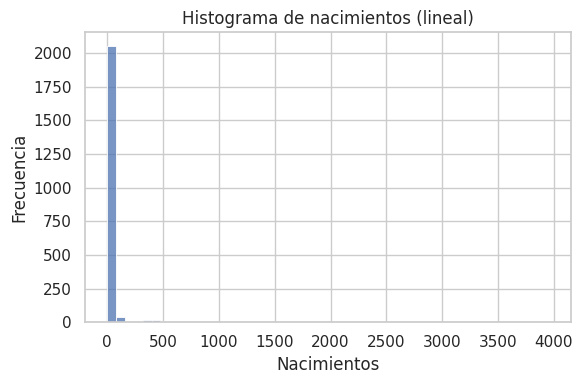

In [19]:
sns.set(style="whitegrid")

# Histograma en escala lineal (Y)
plt.figure(figsize=(6,4))
ax = sns.histplot(data=df_prov, x="CUENTA", bins=50)
ax.set_title("Histograma de nacimientos (lineal)")
ax.set_xlabel("Nacimientos")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()



**Resultado GRAF. 1:** El histograma evidencia una fuerte asimetría positiva: la mayoría de los casos presentan pocos nacimientos y existen pocos valores extremos altos

Se decide pasar a Log10 para ver una mejor distribución de los datos

**GRAF. 2:** Histogramas con escala log en Y para visualizar cola larga. IQR usado solo como screening (309 combinaciones señaladas).

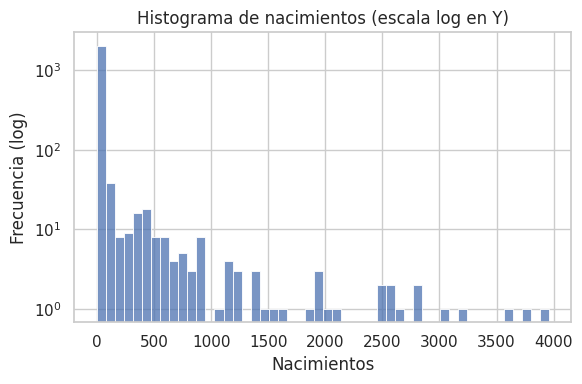

In [20]:
# Histograma con eje Y en log
plt.figure(figsize=(6,4))
ax = sns.histplot(data=df_prov, x="CUENTA", bins=50)
ax.set_yscale("log")  # log en el eje Y
ax.set_title("Histograma de nacimientos (escala log en Y)")
ax.set_xlabel("Nacimientos")
ax.set_ylabel("Frecuencia (log)")
plt.tight_layout()
plt.show()

**Resultado GRAF.2:** Al aplicar escala logarítmica se visualiza mejor la variabilidad: la mayoría de los valores son bajos, pero existen varios casos con nacimientos mucho más altos que funcionan como outliers. La distribución esta fuertemente sesgada pero los valores altos parecen plausibles por frecuencia de combinaciones. No se eliminan filas.

En totales no se detectaron outliers; la caída 2019 - 2023 es consistente. A nivel fila, el IQR señaló 309 casos. Se inspeccionaron los mayores y son plausibles. No se eliminaron observaciones; el IQR se usó solo como herramienta de inspección.

## Estadistico 2: Variación porcentual de cada provincia (2019→2023).

Con el fin de caracterizar la evolución intraprovincial, utilizo 2019 como línea de base y estimo la variación porcentual propia de cada provincia:
 Δ% = [(N_2023 − N_2019) / N_2019] × 100.
 Indicando aumentos o descensos locales sin verse afectado por diferencias de tamaño entre provincias.


In [21]:
# Totales por Año×Provincia (lo hago nuevamente para tener certeza)
totales = (df_prov.groupby(["Año","PROVINCIA"], as_index=False)["CUENTA"]
                   .sum()
                   .rename(columns={"CUENTA":"nacimientos"}))

# Filtro nuevamente las provincias
t2 = totales[totales["PROVINCIA"].isin(["Córdoba","Chaco"])].copy()

# Paso a formato ancho y calculo ΔN y %
wide = t2.pivot(index="PROVINCIA", columns="Año", values="nacimientos")
wide["Δnacimientos (2023-2019)"] = wide[2023] - wide[2019]
wide["% cambio self (vs 2019)"] = (wide["Δnacimientos (2023-2019)"] / wide[2019] * 100).round(2)

wide.reset_index()[["PROVINCIA", 2019, 2023, "Δnacimientos (2023-2019)", "% cambio self (vs 2019)"]]

Año,PROVINCIA,2019,2023,Δnacimientos (2023-2019),% cambio self (vs 2019)
0,Chaco,22176,16769,-5407,-24.38
1,Córdoba,50929,38126,-12803,-25.14


Conclusión: En comparacion con la línea base del 2019, Chaco disminuyo en un −24,38% su N total de nacimientos en el 2023, y Córdoba un −25,14%.

# Features


Comparamos % bajo peso, % madres adolescentes y % de nacimientos prematuros en 2019 con respecto al 2023, en las provincias de Chaco y Cordoba.

Guía:
* Madre adolescente: < 20 años
* Nacimiento prematuro: < 37 semanas de gestación
* Bajo peso al nacer: < 2500g

El % se calcula sobre total de nacimientos con el dato conocido para esa variable (excluye “Sin especificar”).Aquí si decidimos excluir los datos "sin especificar" para que no interfiera en la totalidad de la proporcion por variable y tener un resultado mas certero.

In [22]:
df_f = df_prov.copy()

#Guía:
#    IMEDAD: 1./2. = <20 ; 9. = sin especificar
#    ITIEMGEST: 1..5 = <37 ; 8. = sin especificar
#    IPESONAC: 1. = <2500 ; 3. = sin especificar
df_f["madre_adolescente"] = df_f["IMEDAD"].astype(str).str.startswith(("1.","2.")).astype(int)
df_f["prematuro"]         = df_f["ITIEMGEST"].astype(str).str.startswith(("1.","2.","3.","4.","5.")).astype(int)
df_f["bajo_peso"]         = df_f["IPESONAC"].astype(str).str.startswith("1.").astype(int)

# 2) Función de proporción ponderada por CUENTA, excluyendo "sin especificar" en el denominador de CADA variable
def props(g):
    # Mascaras de denominador limpio por variable
    g_edad = g[~g["IMEDAD"].astype(str).str.startswith("9.")]
    g_gest = g[~g["ITIEMGEST"].astype(str).str.startswith("8.")]
    g_peso = g[~g["IPESONAC"].astype(str).str.startswith("3.")]

    def wprop(gg, flag_col):
        den = gg["CUENTA"].sum()
        num = (gg[flag_col] * gg["CUENTA"]).sum()
        return num/den if den else np.nan

    return pd.Series({
        "pct_madre_adolescente": wprop(g_edad, "madre_adolescente"),  # proporción 0–1
        "pct_prematuro":         wprop(g_gest, "prematuro"),
        "pct_bajo_peso":         wprop(g_peso, "bajo_peso"),
    })

# 3) Calcular por Año x Provincia
features = (df_f.groupby(["Año","PROVINCIA"], as_index=False)
              .apply(props)
              .reset_index(drop=True))

features.head()

/tmp/ipython-input-450009829.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(props)


,Año,PROVINCIA,pct_madre_adolescente,pct_prematuro,pct_bajo_peso
0,2019,Chaco,0.177276,0.099186,0.082258
1,2019,Córdoba,0.102813,0.081165,0.071822
2,2023,Chaco,0.131322,0.087898,0.093479
3,2023,Córdoba,0.082168,0.085211,0.078215


Representamos gráficamente lo que vemos en la tabla de arriba:

**FIG.3:** Gráfico de Barras de % Madres adolescentes en Chaco y Córdoba (2019-2023)




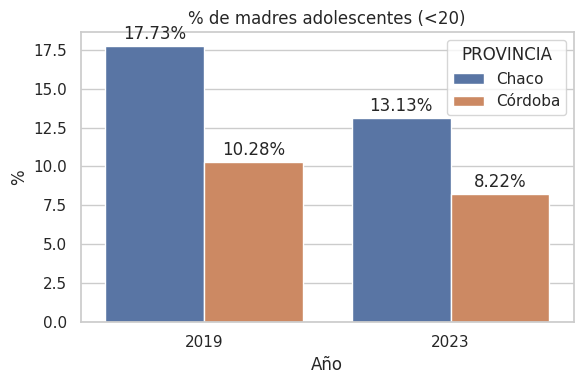

In [23]:
#Gráfico % madre adolescente en Chaco/Córdoba en 2019-2023
plot_df = features.copy()
cols = ["pct_madre_adolescente","pct_prematuro","pct_bajo_peso"]
# Paso a % solo si está en proporción (0–1)
if plot_df["pct_madre_adolescente"].max() <= 1:
    plot_df[cols] = plot_df[cols]*100

sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
ax = sns.barplot(data=plot_df, x="Año", y="pct_madre_adolescente", hue="PROVINCIA")
plt.title("% de madres adolescentes (<20)")
plt.ylabel("%"); plt.xlabel("Año")
for cont in ax.containers: ax.bar_label(cont, fmt="%.2f%%", padding=2)
plt.tight_layout(); plt.show()

**Resultado GRAF.3:** En ambas provincias baja la maternidad adolescente entre 2019 y 2023; la caída es mayor en Chaco.

**FIG.4:** Gráfico de Barras de % de bajo peso al nacer en Chaco y Córdoba (2019-2023)



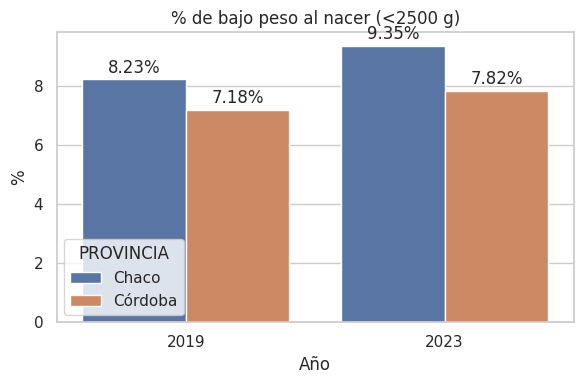

In [24]:
#Gráfico % bajo peso al nacer en Chaco/Córdoba en 2019-2023
plt.figure(figsize=(6,4))
ax = sns.barplot(data=plot_df, x="Año", y="pct_bajo_peso", hue="PROVINCIA")
plt.title("% de bajo peso al nacer (<2500 g)")
plt.ylabel("%"); plt.xlabel("Año")
for cont in ax.containers: ax.bar_label(cont, fmt="%.2f%%", padding=2)
plt.tight_layout(); plt.show()

**Resultado GRAF. 4:** El bajo peso muestra una suba general en 2023; descriptivamente Chaco sube levemente más que Córdoba.

**FIG.5:** Gráfico de Barras de % de nacimientos prematuros en Chaco y Córdoba (2019-2023)



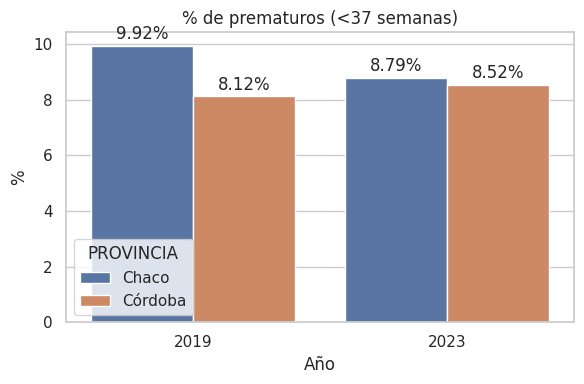

In [25]:
#Gráfico % nacimientos prematuros en Chaco/Córdoba en 2019-2023
plt.figure(figsize=(6,4))
ax = sns.barplot(data=plot_df, x="Año", y="pct_prematuro", hue="PROVINCIA")
plt.title("% de prematuros (<37 semanas)")
plt.ylabel("%"); plt.xlabel("Año")
for cont in ax.containers: ax.bar_label(cont, fmt="%.2f%%", padding=2)
plt.tight_layout(); plt.show()

**Resultado GRAF. 5:** Los nacimientos prematuros se mantiene similar entre provincias en 2023. En Chaco disminuye levemente y en Córdoba aumenta sutilmente.

***Resultados generales:***

% madres adolescentes (<20 años): Chaco es claramente más alto que Córdoba en ambos años. De 2019 → 2023 cae en ambas provincias (mejoría deseable).

% bajo peso al nacer (<2.500 g):Chaco está ligeramente por encima de Córdoba en 2019.En 2023 parece subir en Chaco y bajar o quedar similar en Córdoba.

% nacimientos prematuros (<37 semanas): Niveles similares entre provincias. Estables o con cambio leve entre 2019 y 2023.



## Conclusiones



Entre 2019 y 2023 se observa una disminución general del número de nacimientos en ambas provincias y una mejoría en la maternidad adolescente, posiblemente relacionada con esa baja general. En contraste, el porcentaje de nacimientos con bajo peso muestra un leve aumento, más pronunciado en Chaco, mientras que los nacimientos prematuros se mantiene estable y sin diferencias relevantes entre regiones.

En conjunto, Chaco presenta una mayor vulnerabilidad relativa, con más casos de madres adolescentes y bajo peso al nacer.

Sería importante verificar la calidad de los datos, ya que la ausencia total de outliers, ni errores, puede indicar también sospecha de la calidad de estos datos. Además, para un análisis más sólido, se recomienda incluir los años 2020, 2021 y 2022 (periodo de pandemia) y comparar con otras regiones con diferentes características climáticas o socioeconómicas, para comprender mejor los factores asociados a las variaciones observadas.

